In [ ]:
import os
from parse_planner_output import extract_tfd_plan, extract_enhsp_plan, extract_metricff_plan, extract_nfd_plan
from schedule_to_plan import extract_info, count_moves_until_2nd_service, make_new_schedule, make_new_new_schedule

In [ ]:
import json
import os
import networkx as nx
from plan import PartialPlan
from old.run_mzn import run_mzn
from old.mzn_arr_to_schedule import *
from objects import Service, Movement

In [ ]:
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import scienceplots

In [ ]:
walking_distances = {
    ("entry", "52"):3,
    ("entry", "53"):4,
    ("entry", "54"):5,
    ("entry", "55"):6,
    ("entry", "56"):7,
    ("entry", "57"):8,
    ("entry", "58"):9,
    ("entry", "59"):10,
    ("entry", "60"):8,
    ("entry", "61_service"):9,
    ("entry", "62_service"):10,
    ("entry", "63"):12,
    ("52", "53"):1,
    ("52", "54"):2,
    ("52", "55"):3,
    ("52", "56"):4,
    ("52", "57"):5,
    ("52", "58"):6,
    ("52", "59"):7,
    ("52", "60"):5,
    ("52", "61_service"):6,
    ("52", "62_service"):7,
    ("52", "63"):10,
    ("53", "54"):1,
    ("53", "55"):2,
    ("53", "56"):3,
    ("53", "57"):4,
    ("53", "58"):5,
    ("53", "59"):6,
    ("53", "60"):4,
    ("53", "61_service"):5,
    ("53", "62_service"):6,
    ("53", "63"):9,
    ("54", "55"):1,
    ("54", "56"):2,
    ("54", "57"):3,
    ("54", "58"):4,
    ("54", "59"):5,
    ("54", "60"):3,
    ("54", "61_service"):4,
    ("54", "62_service"):5,
    ("54", "63"):8,
    ("55", "56"):1,
    ("55", "57"):2,
    ("55", "58"):3,
    ("55", "59"):4,
    ("55", "60"):4,
    ("55", "61_service"):3,
    ("55", "62_service"):4,
    ("55", "63"):7,
    ("56", "57"):1,
    ("56", "58"):2,
    ("56", "59"):3,
    ("56", "60"):5,
    ("56", "61_service"):4,
    ("56", "62_service"):3,
    ("56", "63"):6,
    ("57", "58"):1,
    ("57", "59"):2,
    ("57", "60"):6,
    ("57", "61_service"):5,
    ("57", "62_service"):4,
    ("57", "63"):7,
    ("58", "59"):1,
    ("58", "60"):7,
    ("58", "61_service"):6,
    ("58", "62_service"):5,
    ("58", "63"):8,
    ("59", "60"):8,
    ("59", "61_service"):7,
    ("59", "62_service"):6,
    ("59", "63"):9,
    ("60", "61_service"):1,
    ("60", "62_service"):2,
    ("60", "63"):4,
    ("61_service", "62_service"):1,
    ("61_service", "63"):3,
    ("62_service", "63"):4,
}

In [ ]:
folders = [
    '../results/tfd/base1', 
    '../results/tfd/base2', 
    '../results/enhsp/base3', 
    '../results/enhsp/base4',
    '../results/nfd/base3',
    '../results/metricff/base3', 
]

In [ ]:
number_moves = []
makespans = []


for folder in folders:
    for cfg in range(1,22):
        for num_t in range(3,20):

            plan_file = f'{folder}/pln_{cfg}_{num_t}t.txt'

            if not os.path.exists(plan_file):
                continue

            if 'tfd' in folder:
                all_plans = extract_tfd_plan(plan_file)
            elif 'enhsp' in folder:
                all_plans, _, _, _ = extract_enhsp_plan(plan_file)
            elif 'metricff' in folder:
                all_plans, _, _ = extract_metricff_plan(plan_file)
                for i in range(len(all_plans)):
                    all_plans[i] = [f'({l.split(': ')[-1][:-1].lower()})' for l in all_plans[i]]
            elif 'nfd' in folder:
                plan = extract_nfd_plan(plan_file)
                all_plans = [plan]
            else:
                continue

            if len(all_plans) < 1:
                continue

            best_plan = all_plans[0]
            actions, trains, tracks = extract_info(best_plan)
            
            pp = PartialPlan(best_plan)
            pp.build_constraints()
            pp.build_walking_times_matrix(walking_distances)
            pp.write_dzn(1)

            [start_times, durations, action_driver, action_train] = run_mzn(300, 'chuffed')
            train_schedule, driver_schedule = init_train_driver_schedules(start_times,durations, 
                                                                            action_train, action_driver)
            makespan = max([start_times[i]+durations[i] for i in range(len(start_times))])

            new_schedule = make_new_schedule(pp, start_times)
            new_new_schedule = make_new_new_schedule(new_schedule)
            num_moves = count_moves_until_2nd_service(new_new_schedule)
            
            number_moves.append(num_moves)
            makespans.append(makespan)

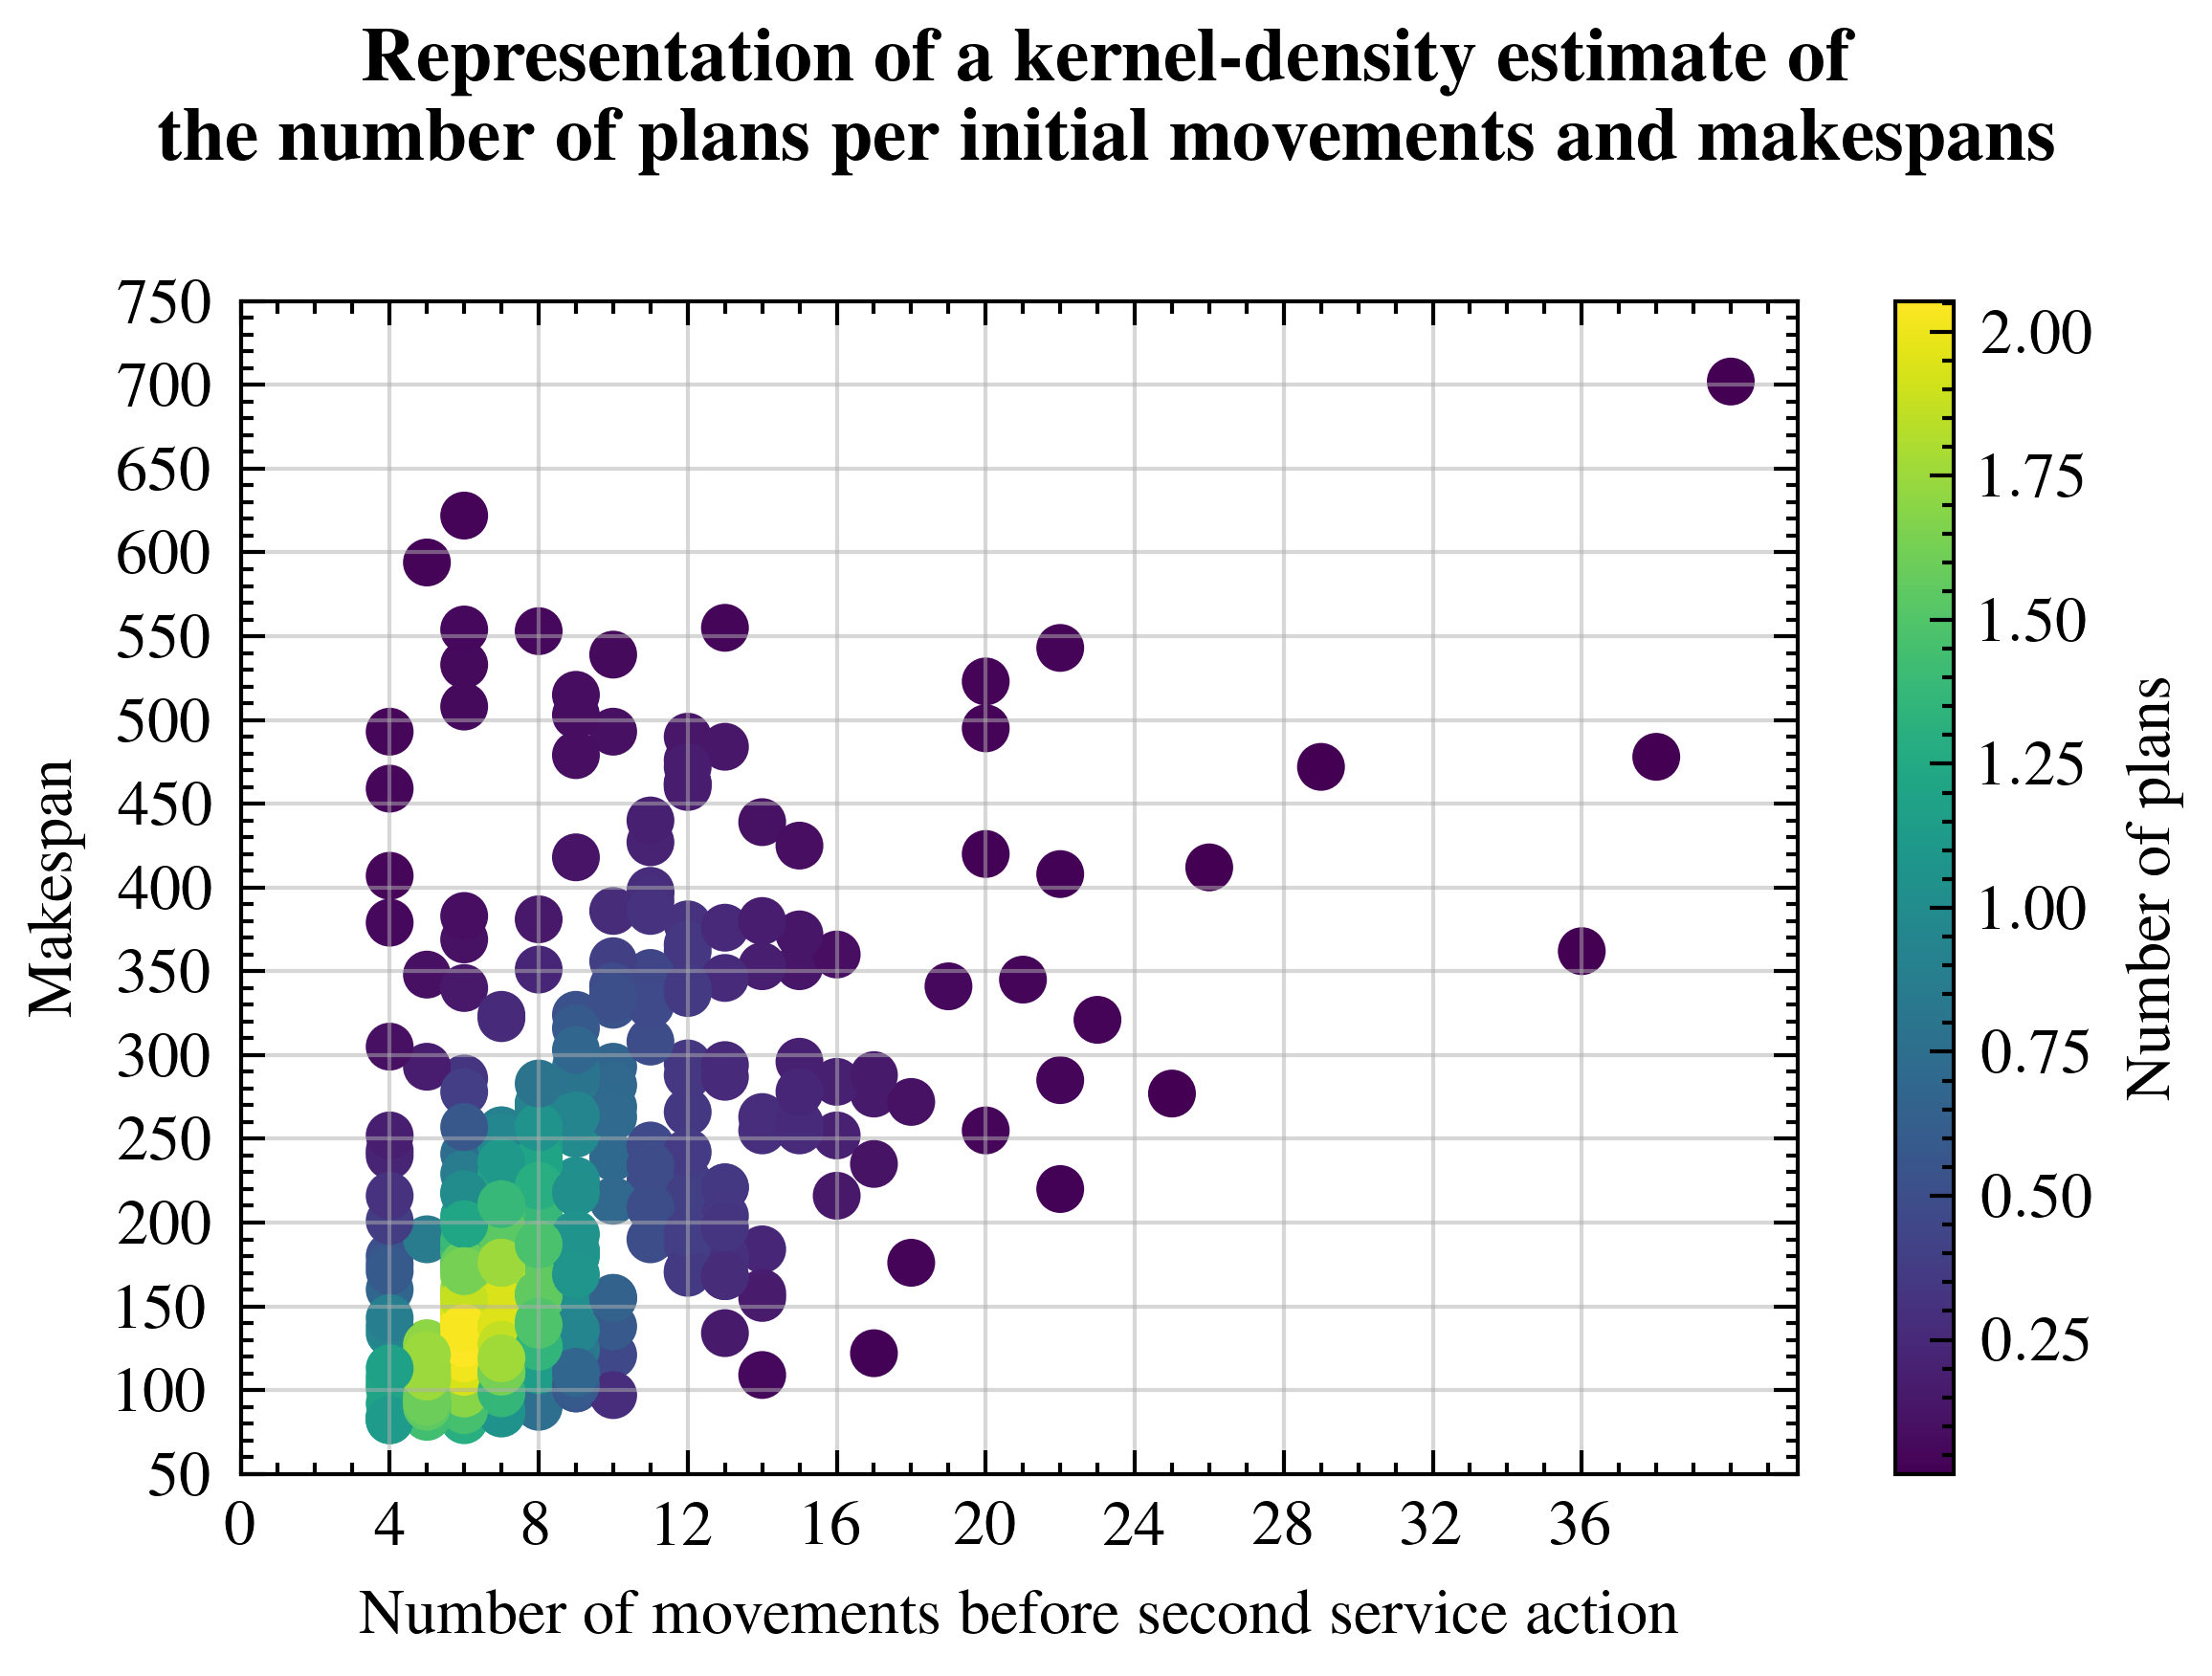

In [91]:
from scipy.stats import gaussian_kde

plt.style.use(['ieee', 'science'])

makespans = [makespans[i] for i in range(len(makespans)) if number_moves[i] <= 40]
number_moves = [number_moves[i] for i in range(len(number_moves)) if number_moves[i] <= 40]

xy = np.vstack([number_moves,makespans])
z = gaussian_kde(xy)
# data_space = np.linspace(xy.min(), xy.max())
evaluated = z.evaluate(xy)
evaluated /= sum(evaluated)
evaluated *= len(makespans)

fig, ax = plt.subplots(figsize=(4,3))
fig.suptitle(r"""\textbf{Representation of a kernel-density estimate of}
             \textbf{the number of plans per initial movements and makespans}""")
density = ax.scatter(number_moves, makespans, c=evaluated, s=25)
ax.grid(True, alpha=0.5)

ax.set_xlabel('Number of movements before second service action')
ax.set_ylabel('Makespan')
ax.set_xticks([i * 4 for i in range(10)])
ax.set_yticks([i * 50 for i in range(1,16)])

plt.tight_layout()
fig.colorbar(density, label='Number of plans')
fig.savefig('until_2service.png')


In [ ]:
evaluated = z.evaluate(np.linspace(xy.min(), xy.max(), 100))

In [79]:
sum(evaluated)

0.14392710678982304